# GSE296969 初步分析
结肠组织 基质细胞 样本，13个样本  
7UC，6HC
- U68-UC74
- HC89-HC94

# 文件说明
- **文件名**: 10_GSE296969.h5ad  
- **存放位置**: 坚果云  `UC/scRNA-seq_data/data_qc/`  
- **生成日期**: 2025-11-1  
- **生成者**: Jiang Lai
- **对应脚本**: notebooks/1_preprocessing/10_GSE296969_preprocessing.ipynb  
- **内容说明**: 包含质控和去除双细胞后的数据集数据，保存为h5ad文件，方便后续合并时读取  

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(dpi=50)
ov.settings.verbose = 1 
#ov.settings.cpu_gpu_mixed_init()

/home/hg/miniconda3/envs/omic/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


🔬 Starting plot initialization...
🧬 Detecting CUDA devices…
✅ [GPU 0] NVIDIA GeForce RTX 5060 Ti
    • Total memory: 15.9 GB
    • Compute capability: 12.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.7   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
!pwd

/home/hg/UC_Treg_Project/notebooks/1_preprocessing


## 读取MTX类型数据

In [3]:
import os

data_dirs = ["/mnt/e/UC/scRNA-seq_RAW/10_GSE296969"]
adatas = []

for data_dir in data_dirs:
    for sample in sorted(os.listdir(data_dir)):
        path = os.path.join(data_dir, sample)
        if not os.path.isdir(path):
            continue

        ad = sc.read_10x_mtx(path, var_names='gene_symbols', cache=False)
        sc.pp.filter_cells(ad, min_genes=200)
        sc.pp.filter_genes(ad, min_cells=3)

        ad.obs['GSM_id'] = sample
        ad.obs_names = [f"{sample}_{x}" for x in ad.obs_names] 
        adatas.append(ad)     

adata = sc.concat(adatas, merge='same')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 1918 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 6 cells that have less than 200 genes expressed
filtered out 3794 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 2881 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 2528 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
filtered out 2423 genes that are detected in less than 3 cells
--> This might be very slow. Consider passing `cache=True`,

In [4]:
adata

AnnData object with n_obs × n_vars = 106310 × 27980
    obs: 'n_genes', 'GSM_id'
    var: 'gene_ids', 'feature_types'

In [5]:
adata.obs['GSM_id'].value_counts()

GSM_id
GSM8980880_HC90    11308
GSM8980882_UC70    10225
GSM8980878_UC68    10208
GSM8980887_UC73     9906
GSM8980885_HC91     9008
GSM8980886_HC92     8981
GSM8980889_HC94     7975
GSM8980881_UC69     7459
GSM8980879_HC89     7078
GSM8980888_HC93     6766
GSM8980884_UC72     6409
GSM8980890_UC74     5507
GSM8980883_UC71     5480
Name: count, dtype: int64

In [6]:
adata.obs['GSM'] = adata.obs['GSM_id'].str.split("_").str[0]  
adata.obs['id']  = adata.obs['GSM_id'].str.split("_").str[1]  

In [7]:
output_dir = "/mnt/c/Users/Future/Nutstore/1/UC/scRNA-seq_data/data_raw/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "10_GSE29696_combined.h5ad"), compression='gzip')

In [3]:
adata = sc.read_h5ad("/mnt/c/Users/Administrator/Nutstore/2/UC/scRNA-seq_data/data_raw/10_GSE29696_combined.h5ad")

## 预处理步骤
- QC: mito<0.2, UMI>500, genes>250, 去除双细胞
- HVG: Pearson方法，2000个
- PCA: 50个PCs
- neighbors: 最邻近数15，使用前50PCs
- leiden: resolution0.5

In [4]:
# QC
adata=ov.pp.qc(adata,
               tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
               doublets_method='scrublet',
               batch_key=None)

adata

🖥️ Using CPU mode for QC...

📊 Step 1: Calculating QC Metrics
   Mitochondrial genes (prefix 'MT-'): 13 found
   ✓ QC metrics calculated:
     • Mean nUMIs: 4621 (range: 518-78554)
     • Mean genes: 2081 (range: 196-11376)
     • Mean mitochondrial %: 5.0% (max: 81.1%)
   📈 Original cell count: 106,310

🔧 Step 2: Quality Filtering (SEURAT)
   Thresholds: mito≤0.2, nUMIs≥500, genes≥250
   📊 Seurat Filter Results:
     • nUMIs filter (≥500): 0 cells failed (0.0%)
     • Genes filter (≥250): 38 cells failed (0.0%)
     • Mitochondrial filter (≤0.2): 624 cells failed (0.6%)
   ✓ Filters applied successfully
   ✓ Combined QC filters: 662 cells removed (0.6%)

🎯 Step 3: Final Filtering
   Parameters: min_genes=200, min_cells=3
   Ratios: max_genes_ratio=1, max_cells_ratio=1
   ✓ Final filtering: 0 cells, 0 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work properly
   💡 Consider using 'doublets_method=sccomposite' for better results
   🔍

AnnData object with n_obs × n_vars = 105648 × 27980
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

In [5]:
adata


AnnData object with n_obs × n_vars = 105648 × 27980
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

## 保存质控后数据（去除双细胞）


In [8]:
import os
output_dir = "/mnt/d/data/UC/"
os.makedirs(output_dir, exist_ok=True)
adata.write_h5ad(os.path.join(output_dir, "10_GSE29696.h5ad"), compression='gzip')

In [9]:
# HVG
adata=ov.pp.preprocess(adata,
                       mode='shiftlog|pearson',
                       n_HVGs=2000,
                       target_sum=50*1e4)

adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]

# PCA
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

# Embedding the neighborhood graph
ov.pp.neighbors(adata, 
                n_neighbors=15, 
                n_pcs=50,
                use_rep='scaled|original|X_pca')

# UMAP
ov.pp.umap(adata)

# Clustering
ov.pp.leiden(adata,resolution=0.5)

Begin robust gene identification
After filtration, 27980/27980 genes are kept.     Among 27980 genes, 27980 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell
The following highly-expressed genes are not considered during normalization factor computation:
['IGKC', 'HBB', 'HBG2', 'MALAT1', 'IGHA1', 'IGHA2', 'IGHG4', 'IGHG3', 'IGHM', 'IGLC2', 'IGLC3', 'IGLL5']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 10.986098289489746 seconds.
End of size normalization: shiftlog and HVGs selection pearson
computing

In [10]:
adata

AnnData object with n_obs × n_vars = 105648 × 2000
    obs: 'n_genes', 'GSM_id', 'GSM', 'id', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'scaled|original|X_pca', 'X_umap'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'
    obsp: 'distances', 'connectivities'

指控后每个样本细胞数

In [11]:
adata.obs['id'].value_counts()

id
HC90    11289
UC70    10199
UC68    10169
UC73     9875
HC91     8991
HC92     8972
HC94     7945
UC69     7179
HC89     7030
HC93     6738
UC72     6373
UC71     5455
UC74     5433
Name: count, dtype: int64

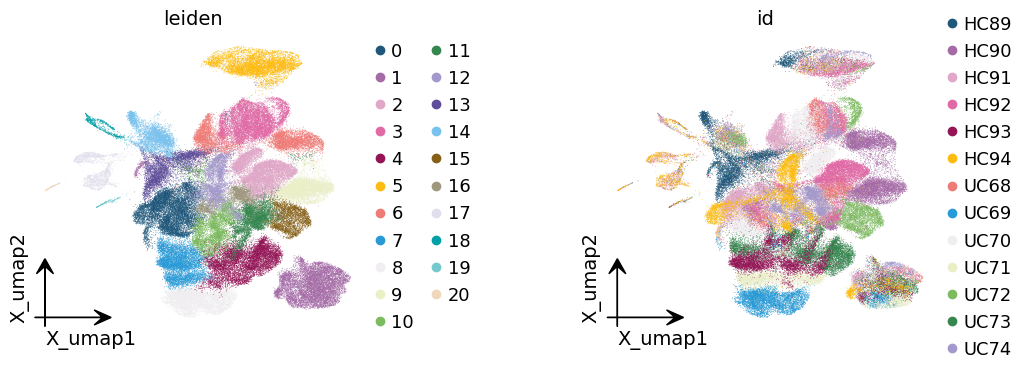

In [12]:
# 可视化查看聚类和样本分布
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'id'],
                frameon='small',
                wspace=0.5)

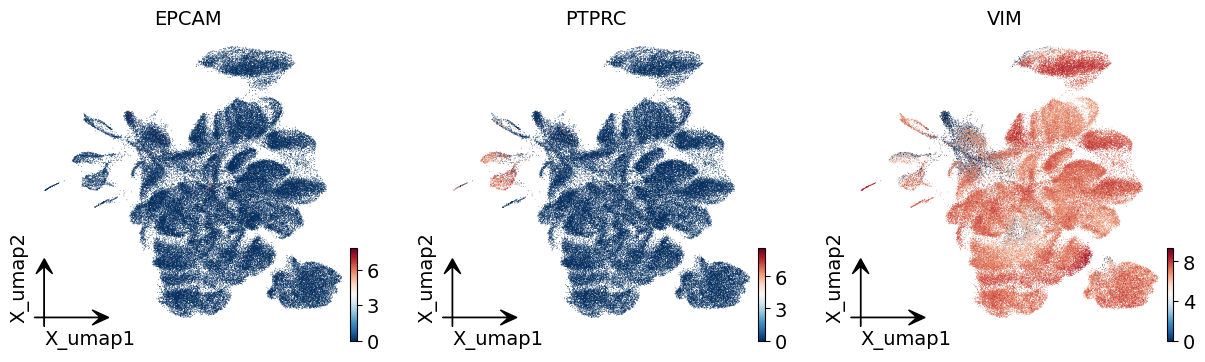

In [13]:
# 粗略查看上皮、免疫、基质细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['EPCAM', 'PTPRC', 'VIM'],
                frameon='small')

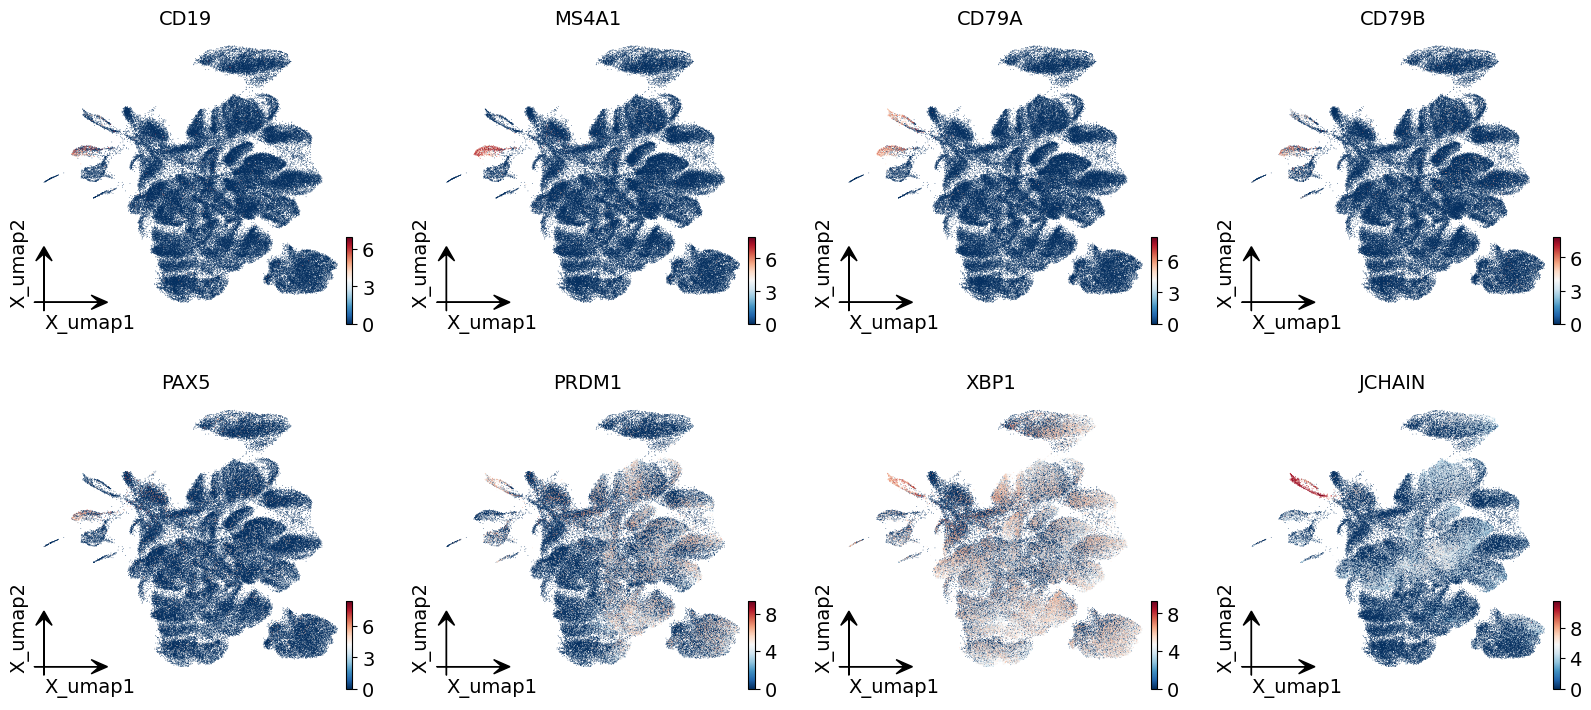

In [14]:
# 查看B细胞和浆细胞
ov.pl.embedding(adata,
                basis='X_umap',
                color=['CD19', 'MS4A1', 'CD79A', 'CD79B', 'PAX5', 'PRDM1', 'XBP1', 'JCHAIN'],
                frameon='small')

## GPT自动注释

In [15]:
# 获取每个细胞群的基因
all_markers = ov.single.get_celltype_marker(adata,
                                            clustertype='leiden',
                                            rank=True,
                                            key='rank_genes_groups',
                                            foldchange=1,
                                            topgenenumber=10)
all_markers

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:23)


{'0': ['DCN',
  'LUM',
  'GSN',
  'CXCL12',
  'FBLN1',
  'CCDC80',
  'C7',
  'COL14A1',
  'C3',
  'MGP'],
 '1': ['NOTCH3',
  'IGFBP7',
  'COL4A1',
  'EPAS1',
  'RGS5',
  'ADAMTS1',
  'PDGFRB',
  'MYL9',
  'MCAM',
  'NR2F2'],
 '10': ['PDE4D',
  'MAML2',
  'GPC6',
  'PRKG1',
  'RORA',
  'SIK3',
  'SDK1',
  'AC098650.1',
  'AC016831.7',
  'NEAT1'],
 '11': ['HHIP',
  'MYH11',
  'MYL6',
  'TPM1',
  'ACTA2',
  'MYL9',
  'FLNA',
  'MYLK',
  'TAGLN',
  'ACTG2'],
 '12': ['CD74',
  'CCL19',
  'C1S',
  'HLA-C',
  'CXCL14',
  'CTSK',
  'RARRES2',
  'UBD',
  'C3',
  'C1R'],
 '13': ['AL078604.2', 'AL078604.4', 'SEMA4A'],
 '14': ['COL19A1'],
 '15': ['CTSC',
  'CFD',
  'ADAMDEC1',
  'WARS',
  'FN1',
  'CFH',
  'SCARA5',
  'TSC22D3',
  'MT2A',
  'LTBP4'],
 '16': ['IGHA2',
  'IGLL5',
  'SLC26A3',
  'IGHA1',
  'SLC27A4',
  'IGLC2',
  'MTRNR2L8',
  'IGKC',
  'MTRNR2L1',
  'RASGEF1B'],
 '17': ['TMSB4X',
  'SRGN',
  'LAPTM5',
  'RPS29',
  'CXCR4',
  'PTPRC',
  'RPS27',
  'EZR',
  'BTG1',
  'ARHGDIB'],
 '18'

In [16]:
import os
os.environ['AGI_API_KEY'] = 'sk-ff0dc715f640466393e6aa71c9da6848'
result = ov.single.gptcelltype(all_markers,
                               tissuename='Stromal ',
                               speciename='human',
                               model='qwen-plus',
                               provider='qwen',
                               topgenenumber=10)
result

Note: AGI API key found: returning the cell type annotations.
Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Fibroblasts',
 '1': 'Pericytes',
 '10': 'Perivascular cells',
 '11': 'Vascular smooth muscle cells',
 '12': 'Dendritic cells',
 '13': 'Plasmacytoid dendritic cells',
 '14': 'Collagen-producing cells',
 '15': 'Macrophages',
 '16': 'Plasma cells',
 '17': 'T cells',
 '18': 'Plasma cells',
 '19': 'Endothelial cells',
 '2': 'Macrophages',
 '20': 'Mast cells',
 '3': 'Fibroblasts',
 '4': 'Pericytes',
 '5': 'Oligodendrocytes',
 '6': 'Fibroblasts',
 '7': 'Fibroblasts',
 '8': 'Ribosomal protein-expressing cells',
 '9': 'Macrophages'}

In [17]:
# 添加识别结果到obs
adata.obs['gpt_celltype'] = adata.obs['leiden'].map(result).astype('category')

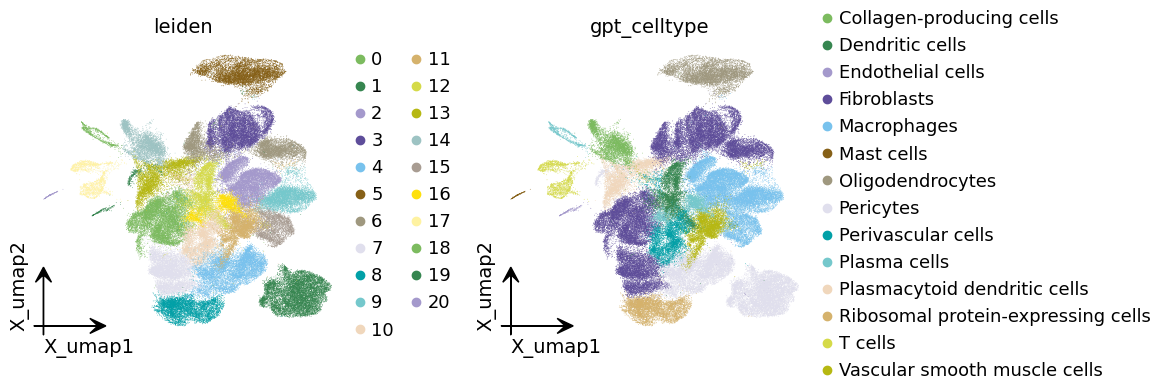

In [18]:
# 可视化查看结果
ov.pl.embedding(adata,
                basis='X_umap',
                color=['leiden', 'gpt_celltype'],
                # legend_loc='on data',
                frameon='small',
                legend_fontoutline=0.5,
                palette=ov.utils.palette()[10:],
                wspace=0.3)

In [19]:
# 统计每种细胞类型数量及占比
celltype_counts = adata.obs['gpt_celltype'].value_counts(normalize=True) * 100
print(celltype_counts)

gpt_celltype
Fibroblasts                           28.876079
Pericytes                             16.648682
Macrophages                           16.450856
Oligodendrocytes                       6.035136
Ribosomal protein-expressing cells     5.093329
Perivascular cells                     4.757307
Vascular smooth muscle cells           4.616273
Dendritic cells                        4.599235
Plasmacytoid dendritic cells           4.404248
Collagen-producing cells               3.870400
Plasma cells                           2.718461
T cells                                1.636567
Endothelial cells                      0.170377
Mast cells                             0.123050
Name: proportion, dtype: float64
